# Member 1 - Linear Regression
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using the preprocessed insurance dataset.

### Model Suitability
Linear Regression is suitable as a baseline model because the target variable, `charges`, is continuous. The model estimates the relationship between the input features and medical insurance charges using a linear equation.

It is simple and interpretable, which makes it useful as a baseline for comparison with more complex regression models such as Ridge Regression, SVR, Decision Tree, Random Forest, and KNN.

Since Linear Regression has very few model-specific hyperparameters, different feature configurations are evaluated as model variants.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Find the project root automatically
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
# Load processed datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())


print("\nTesting Data:")
display(test_df.head())


print("\nTraining Columns:")
print(train_df.columns.tolist())


print("\nTesting Columns:")
print(test_df.columns.tolist())


print(
    "\nTraining Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Testing Missing Values:",
    test_df.isnull().sum().sum()
)

print(
    "Training Duplicates:",
    train_df.duplicated().sum()
)

print(
    "Testing Duplicates:",
    test_df.duplicated().sum()
)


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Columns:
['smoker_yes', 'age_bmi_interaction', 'age', 'bmi', 'region_southeast', 'children', 'sex_male', 'charges']

Testing Columns:
['smoker_yes', 'age_bmi_interaction', 'age', 'bmi', 'region_southeast', 'children', 'sex_male', 'charges']

Training Missing Values: 0
Testing Missing Values: 0
Training Duplicates: 0
Testing Duplicates: 0


In [4]:
# Separate input features and target
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


# Verify train/test feature consistency
if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
Three regression evaluation metrics are used:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted insurance charges. Lower values indicate better performance.
- **RMSE (Root Mean Squared Error):** Gives a larger penalty to large prediction errors. Lower values indicate better performance.
- **R² Score:** Measures how much of the variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation Method
Five-fold cross-validation is used to evaluate model consistency. The training data is divided into five folds. During each iteration, four folds are used for training and one fold is used for validation. This process is repeated until every fold has been used for validation.

### Implementation Details
Pandas and NumPy are used for data handling and numerical operations, Matplotlib is used for visualization, and Scikit-learn is used for model implementation and evaluation.

Three Linear Regression configurations are evaluated:

1. Linear Regression using all processed features.
2. Linear Regression using the highest training-set correlation features.
3. Linear Regression using a training-set correlation threshold.

Since Linear Regression has few model-specific tuning hyperparameters, different feature configurations are used to evaluate multiple varieties of the model.

In [6]:
# Variant 1 - Linear Regression using all features
linear_baseline = LinearRegression()


linear_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    linear_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "Linear Regression - All Features",
    y_test,
    baseline_predictions
)


Linear Regression - All Features
--------------------------------------------------
MAE  : 4194.4850
RMSE : 5978.2415
R²   : 0.8055


In [7]:
# Display model coefficients
coefficient_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_baseline.coef_
})


coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)


coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)


print("Linear Regression Coefficients:")
display(coefficient_df)


# Calculate feature correlation using TRAINING DATA ONLY
train_correlation_df = X_train.copy()

train_correlation_df["charges"] = (
    y_train.values
)


correlation_with_target = (
    train_correlation_df
    .corr(numeric_only=True)["charges"]
    .drop("charges")
    .abs()
    .sort_values(
        ascending=False
    )
)


print("\nAbsolute Correlation with Charges:")
display(correlation_with_target)

Linear Regression Coefficients:


,Feature,Coefficient,Absolute_Coefficient
0,smoker_yes,23095.491638,23095.491638
2,age,3547.705018,3547.705018
3,bmi,1951.356444,1951.356444
5,children,635.592410,635.592410
4,region_southeast,-466.271288,466.271288
1,age_bmi_interaction,-95.853329,95.853329
6,sex_male,-84.463753,84.463753



Absolute Correlation with Charges:


smoker_yes             0.774131
age_bmi_interaction    0.313805
age                    0.289691
bmi                    0.179106
children               0.086172
region_southeast       0.078927
sex_male               0.060167
Name: charges, dtype: float64

In [8]:
# Variant 2 - Select top correlated features
number_of_features = min(
    6,
    len(correlation_with_target)
)


top_features = (
    correlation_with_target
    .head(number_of_features)
    .index
    .tolist()
)


print("Selected Top Features:")

for feature in top_features:
    print("-", feature)


X_train_top = X_train[
    top_features
]

X_test_top = X_test[
    top_features
]


linear_top = LinearRegression()


linear_top.fit(
    X_train_top,
    y_train
)


top_predictions = (
    linear_top.predict(
        X_test_top
    )
)


top_result = evaluate_model(
    "Linear Regression - Top Features",
    y_test,
    top_predictions
)

Selected Top Features:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- children
- region_southeast

Linear Regression - Top Features
--------------------------------------------------
MAE  : 4194.7917
RMSE : 5979.2403
R²   : 0.8054


In [9]:
# Variant 3 - Select features using correlation threshold
selected_features = (
    correlation_with_target[
        correlation_with_target >= 0.05
    ]
    .index
    .tolist()
)


# Safety check
if len(selected_features) == 0:
    selected_features = top_features


print("Selected Correlation Threshold Features:")

for feature in selected_features:
    print("-", feature)


X_train_selected = X_train[
    selected_features
]

X_test_selected = X_test[
    selected_features
]


linear_selected = LinearRegression()


linear_selected.fit(
    X_train_selected,
    y_train
)


threshold_predictions = (
    linear_selected.predict(
        X_test_selected
    )
)


threshold_result = evaluate_model(
    "Linear Regression - Correlation Threshold",
    y_test,
    threshold_predictions
)

Selected Correlation Threshold Features:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- children
- region_southeast
- sex_male

Linear Regression - Correlation Threshold
--------------------------------------------------
MAE  : 4194.4850
RMSE : 5978.2415
R²   : 0.8055


In [10]:
linear_results = pd.DataFrame([
    baseline_result,
    top_result,
    threshold_result
])


linear_results = (
    linear_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print("Linear Regression Variant Comparison:")

display(
    linear_results
)

Linear Regression Variant Comparison:


,Model,MAE,RMSE,R2
0,Linear Regression - All Features,4194.484960,5978.241481,0.805506
1,Linear Regression - Correlation Threshold,4194.484960,5978.241481,0.805506
2,Linear Regression - Top Features,4194.791657,5979.240333,0.805441


In [11]:
# Select the configuration with the lowest test RMSE
best_model_name = (
    linear_results
    .iloc[0]["Model"]
)


print(
    "Lowest Test-RMSE Configuration:",
    best_model_name
)


if (
    best_model_name
    == "Linear Regression - All Features"
):

    selected_linear_model = (
        linear_baseline
    )

    selected_X_train = (
        X_train
    )

    selected_predictions = (
        baseline_predictions
    )


elif (
    best_model_name
    == "Linear Regression - Top Features"
):

    selected_linear_model = (
        linear_top
    )

    selected_X_train = (
        X_train_top
    )

    selected_predictions = (
        top_predictions
    )


else:

    selected_linear_model = (
        linear_selected
    )

    selected_X_train = (
        X_train_selected
    )

    selected_predictions = (
        threshold_predictions
    )


# 5-Fold Cross Validation
cv_scores = cross_val_score(

    selected_linear_model,

    selected_X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error"
)


cv_rmse_scores = -cv_scores


print("\n5-Fold CV RMSE Scores:")

for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Lowest Test-RMSE Configuration: Linear Regression - All Features

5-Fold CV RMSE Scores:
Fold 1: 6810.3702
Fold 2: 5750.3068
Fold 3: 5810.4094
Fold 4: 6136.0503
Fold 5: 6109.2994

Mean CV RMSE: 6123.2872
CV RMSE Standard Deviation: 376.6825


In [12]:
final_linear_result = evaluate_model(

    "Linear Regression - Selected Configuration",

    y_test,

    selected_predictions
)


print(
    "\nSelected Configuration:",
    best_model_name
)

print(
    "Mean 5-Fold CV RMSE:",
    round(
        cv_rmse_scores.mean(),
        4
    )
)


Linear Regression - Selected Configuration
--------------------------------------------------
MAE  : 4194.4850
RMSE : 5978.2415
R²   : 0.8055

Selected Configuration: Linear Regression - All Features
Mean 5-Fold CV RMSE: 6123.2872


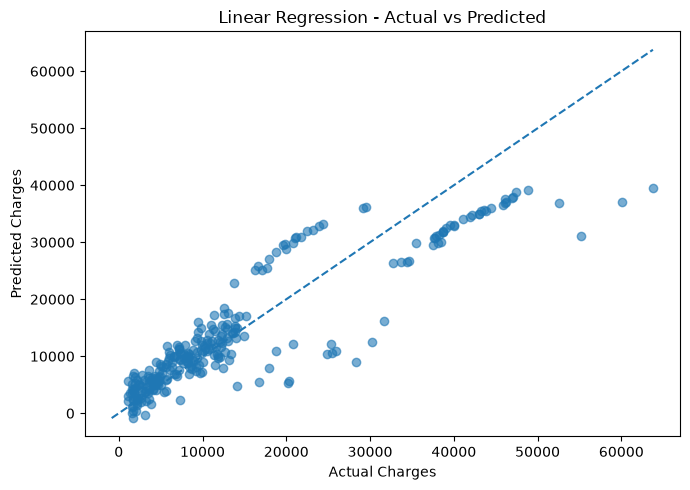

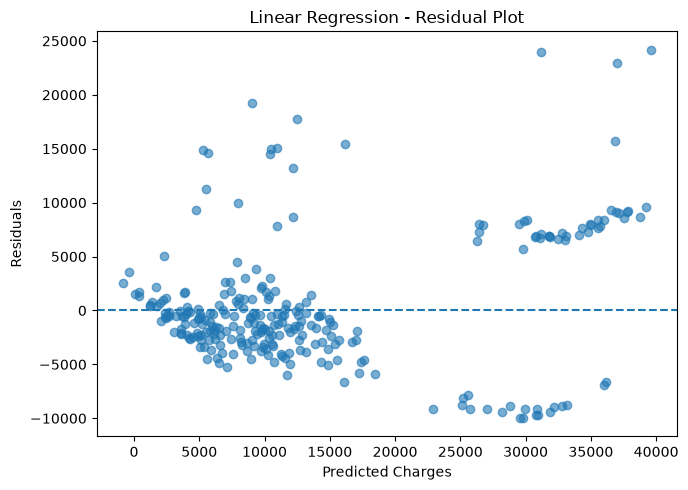

In [13]:
# Actual vs Predicted Plot
plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    selected_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    selected_predictions.min()
)

maximum_value = max(
    y_test.max(),
    selected_predictions.max()
)


plt.plot(
    [
        minimum_value,
        maximum_value
    ],
    [
        minimum_value,
        maximum_value
    ],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "Linear Regression - Actual vs Predicted"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "linear_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ------------------------------------------
# Residual Plot
# ------------------------------------------

residuals = (
    y_test.values
    - selected_predictions
)


plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    selected_predictions,
    residuals,
    alpha=0.6
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Charges"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Linear Regression - Residual Plot"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "linear_residual_plot.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Save all model variants
linear_results.to_csv(

    RESULT_PATH
    / "linear_results.csv",

    index=False
)


# Save selected result for final group comparison
best_linear_result = pd.DataFrame([
    {
        "Model":
            "Linear Regression",

        "Best_Configuration":
            best_model_name,

        "MAE":
            final_linear_result["MAE"],

        "RMSE":
            final_linear_result["RMSE"],

        "R2":
            final_linear_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_linear_result.to_csv(

    RESULT_PATH
    / "linear_best.csv",

    index=False
)


print("All Variant Results:")
display(linear_results)


print("\nSelected Linear Regression Result:")
display(best_linear_result)


print("\nResults saved successfully.")

print(
    "Saved:",
    RESULT_PATH
    / "linear_results.csv"
)

print(
    "Saved:",
    RESULT_PATH
    / "linear_best.csv"
)

All Variant Results:


,Model,MAE,RMSE,R2
0,Linear Regression - All Features,4194.484960,5978.241481,0.805506
1,Linear Regression - Correlation Threshold,4194.484960,5978.241481,0.805506
2,Linear Regression - Top Features,4194.791657,5979.240333,0.805441



Selected Linear Regression Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Linear Regression,Linear Regression - All Features,4194.48496,5978.241481,0.805506,6123.287236



Results saved successfully.
Saved: ..\results\model_results\linear_results.csv
Saved: ..\results\model_results\linear_best.csv


## Conclusion, Limitations and Improvements

### Conclusion
Three Linear Regression configurations were evaluated using MAE, RMSE, R², and five-fold cross-validation. The configurations were compared to determine how different feature sets affect insurance charge prediction.

The configuration with the lowest test RMSE was selected for reporting, while five-fold cross-validation was also used to examine its consistency across the training data. The selected Linear Regression result is saved for the final group-level comparison with the other five regression models.

### Limitations
- Linear Regression assumes a linear relationship between predictors and insurance charges.
- It may not capture complex nonlinear relationships in the dataset.
- The model can be influenced by unusual observations.
- Simple correlation-based feature selection may not capture every type of relationship between a feature and the target.

### Possible Improvements
- Introduce meaningful interaction features.
- Investigate suitable transformations for skewed variables.
- Compare with regularized regression models.
- Compare with nonlinear models such as SVR, Decision Tree, Random Forest, and KNN.
- Use additional validation strategies to examine model stability.